In [113]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')

In [114]:
df  = pd.read_csv('survey_results.csv')
df.head()

,respondent_id,age,gender,zone,occupation,income_levels,consume_frequency(weekly),current_brand,preferable_consumption_size,awareness_of_other_brands,reasons_for_choosing_brands,flavor_preference,purchase_channel,packaging_preference,health_concerns,typical_consumption_situations,price_range
0,R00001,30,M,Urban,Working Professional,<10L,3-4 times,Newcomer,Medium (500 ml),0 to 1,Price,Traditional,Online,Simple,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",100-150
1,R00002,46,F,Metro,Working Professional,> 35L,5-7 times,Established,Medium (500 ml),2 to 4,Quality,Exotic,Retail Store,Premium,Medium (Moderately health-conscious),Social (eg. Parties),200-250
2,R00003,41,F,Rural,Working Professional,> 35L,3-4 times,Newcomer,Medium (500 ml),2 to 4,Availability,Traditional,Retail Store,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",200-250
3,R00004,33,F,Urban,Working Professional,16L - 25L,5-7 times,Newcomer,Medium (500 ml),0 to 1,Brand Reputation,Exotic,Online,Eco-Friendly,Low (Not very concerned),"Active (eg. Sports, gym)",150-200
4,R00005,23,M,Metro,Student,NaN,3-4 times,Established,Medium (500 ml),0 to 1,Availability,Traditional,Online,Premium,Medium (Moderately health-conscious),"Active (eg. Sports, gym)",50-100


In [115]:
duplicated_count = df.duplicated().sum()
duplicated_count

np.int64(10)

In [116]:
if duplicated_count > 0:
    df = df.drop_duplicates()
    print("Duplicate rows removed successfully.")
else:
    print("No duplicate rows found.")

Duplicate rows removed successfully.


In [117]:
df.age.describe()

count    30000.000000
mean        33.048167
std         13.438904
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max        604.000000
Name: age, dtype: float64

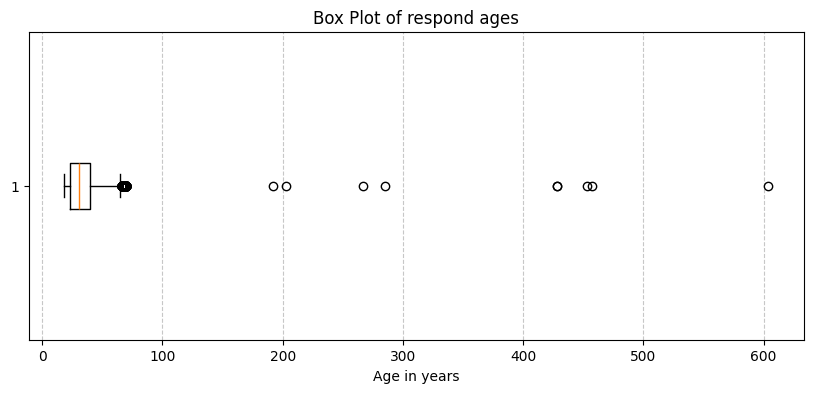

In [118]:
plt.figure(figsize=(10,4))
plt.boxplot(df.age,vert=False)
plt.title('Box Plot of respond ages')
plt.xlabel('Age in years')
plt.grid(True,axis='x',linestyle='--',alpha=0.7)
plt.show()

In [119]:
valid_ages = (df['age']>=18) & (df['age']<=100)
outliers_removed = len(df) - valid_ages.sum()
print(f"Number of outliers removed: {outliers_removed}")
df = df[valid_ages]
df.age.describe()

Number of outliers removed: 9


count    29991.000000
mean        32.947484
std         11.906077
min         18.000000
25%         23.000000
50%         31.000000
75%         40.000000
max         70.000000
Name: age, dtype: float64

In [120]:
missing_income = df['income_levels'].isnull().sum()

if missing_income>0:
    df['income_levels'].fillna('Not Reported',inplace=True)
    print("Missing values replaced with 'Not Reported'")

Missing values replaced with 'Not Reported'


In [121]:
for col in ['consume_frequency(weekly)','purchase_channel']:
    missing_count = df[col].isnull().sum()
    if missing_count > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Missing values in {col} replaced with mode value: {mode_value}")

Missing values in consume_frequency(weekly) replaced with mode value: 3-4 times
Missing values in purchase_channel replaced with mode value: Online


In [122]:
print(df.zone.unique())
print(df.current_brand.unique())

['Urban' 'Metro' 'Rural' 'Semi-Urban' 'Metor' 'urbna']
['Newcomer' 'Established' 'newcomer' 'Establishd']


In [123]:
count_metor = df[df['zone'] == 'Metor'].shape[0]
count_metor

4

In [124]:
correct_spell = {
    'Metor' : 'Metro',
    'urbna' : 'Urban',
    'newcomer' : 'Newcomer',
    'Establishd' : 'Established'

}

df['zone'] = df['zone'].replace(correct_spell)
df['current_brand'] = df['current_brand'].replace(correct_spell)

In [125]:
print(df.zone.unique())
print(df.current_brand.unique())

['Urban' 'Metro' 'Rural' 'Semi-Urban']
['Newcomer' 'Established']


In [126]:
df1 = df.copy()

In [127]:
bins = [17,25,35,45,55,70,150]
labels = ['18-25','26-35','36-45','46-55','56-70','70+']

In [128]:
df1['age_group'] = pd.cut(df['age'],bins=bins,labels=labels)

In [129]:
df1.drop('age',axis=1,inplace=True)
print('Created age_group column')
print(df1['age_group'].value_counts().sort_index())

Created age_group column
age_group
18-25    10468
26-35     9093
36-45     5972
46-55     2966
56-70     1492
70+          0
Name: count, dtype: int64


In [130]:
freq_map = {
    "0-2 times":1,
    "3-4 times":2,
    "5-7 times":3
}

aware_map = {
    "0 to 1":1,
    "2 to 4" : 2,
    "above 4":3
}

In [131]:
freq_score = df1['consume_frequency(weekly)'].map(freq_map)
aware_score = df1['awareness_of_other_brands'].map(aware_map)

In [132]:
freq_score = freq_score.fillna(0)
aware_score = aware_score.fillna(0)

In [133]:
denominator = freq_score + aware_score
df1['cf_ab_score'] = freq_score/denominator

In [134]:
df1['cf_ab_score'] = df1['cf_ab_score'].round(2)

print(df1[['consume_frequency(weekly)','awareness_of_other_brands','cf_ab_score']])

      consume_frequency(weekly) awareness_of_other_brands  cf_ab_score
0                     3-4 times                    0 to 1         0.67
1                     5-7 times                    2 to 4         0.60
2                     3-4 times                    2 to 4         0.50
3                     5-7 times                    0 to 1         0.75
4                     3-4 times                    0 to 1         0.67
...                         ...                       ...          ...
30005                 3-4 times                    2 to 4         0.50
30006                 3-4 times                    2 to 4         0.50
30007                 0-2 times                    0 to 1         0.50
30008                 5-7 times                   above 4         0.50
30009                 5-7 times                   above 4         0.50

[29991 rows x 3 columns]


In [135]:
df1['income_levels'].unique()

array(['<10L', '> 35L', '16L - 25L', 'Not Reported', '10L - 15L',
       '26L - 35L'], dtype=object)

In [136]:
zone_map = {
    "Rural": 1,
    "Semi-Urban": 2,
    "Urban": 3,
    "Metro": 4
}

income_map = {
    "Not Reported": 0,
    "<10L": 1,
    "10L - 15L": 2,
    "16L - 25L": 3,
    "26L - 35L": 4,
    "> 35L": 5
}

In [137]:
z_score = df1['zone'].map(zone_map).fillna(0)
i_score = df1['income_levels'].map(income_map).fillna(0)

In [138]:
df1['zas_score'] = z_score*i_score

df1['zas_score'] = df1['zas_score'].round(2)

print(df1[['zone','income_levels','zas_score']])

        zone income_levels  zas_score
0      Urban          <10L          3
1      Metro         > 35L         20
2      Rural         > 35L          5
3      Urban     16L - 25L          9
4      Metro  Not Reported          0
...      ...           ...        ...
30005  Metro     16L - 25L         12
30006  Urban         > 35L         15
30007  Metro          <10L          4
30008  Urban     16L - 25L          9
30009  Metro  Not Reported          0

[29991 rows x 3 columns]


In [139]:
num_unique = df1['zas_score'].nunique()
unique_values = sorted(df1['zas_score'].unique())

print(f"Number of unique values: {num_unique}")
print(f"Unique values: {unique_values}")

Number of unique values: 14
Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(15), np.int64(16), np.int64(20)]


In [140]:
cond1 = df1['current_brand'] != 'Established'

cond2 = df1['reasons_for_choosing_brands'].isin(['Price','Quality'])

df1['bsi'] = (cond1 & cond2).astype(int)
print(df1['bsi'].value_counts())

bsi
0    20816
1     9175
Name: count, dtype: int64


In [141]:
df2 = df1.copy()

In [142]:
initial_count = len(df2)
initial_count

29991

In [143]:
outlier_condition = (
    (df2['occupation'] == 'Student') &
    (df2['age_group'].isin(['56-70', '70+']))
)

In [144]:
outlier_count = outlier_condition.sum()
outlier_count

np.int64(35)

In [145]:
df_final = df2[~outlier_condition]

In [146]:
final_count = len(df_final)
print(final_count)

if initial_count - final_count == outlier_count:
    print("Outliers removed successfully.")
else:
    print("Outliers not removed successfully.")

29956
Outliers removed successfully.


In [147]:
c1 = df_final['current_brand'] != 'Established'

c2 = df_final['reasons_for_choosing_brands'].isin(['Price','Quality'])

df_final['bsi'] = (c1 & c2).astype(int)
print(df_final['bsi'].value_counts())

bsi
0    20796
1     9160
Name: count, dtype: int64


In [148]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score,classification_report


In [149]:
target_col = 'price_range'
col_to_drop = ['respondent_id',target_col]

X = df_final.drop(columns=col_to_drop)
y = df_final[target_col]
print(X.shape,y.shape)

(29956, 18) (29956,)


In [150]:
label_encoding_col = [
    'age_group',
    'income_levels',
    'health_concerns',
    'consume_frequency(weekly)', 
    'preferable_consumption_size'
]

le = LabelEncoder()

for col in label_encoding_col:
    X[col] = le.fit_transform(X[col])
    print(f"Label encoding applied to {col}")

Label encoding applied to age_group
Label encoding applied to income_levels
Label encoding applied to health_concerns
Label encoding applied to consume_frequency(weekly)
Label encoding applied to preferable_consumption_size


In [151]:
y = le.fit_transform(y)

In [152]:
catrgorical_cols = X.select_dtypes(include=['object']).columns.to_list()
print(catrgorical_cols)

X = pd.get_dummies(X,columns=catrgorical_cols,drop_first=True)
print(X.shape)

['gender', 'zone', 'occupation', 'current_brand', 'awareness_of_other_brands', 'reasons_for_choosing_brands', 'flavor_preference', 'purchase_channel', 'packaging_preference', 'typical_consumption_situations']
(29956, 27)


In [154]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.5,random_state=42)

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(14978, 27) (14978,)
(14978, 27) (14978,)


In [155]:
model_to_train = {
    "GaussianNB": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=1000,random_state=42),
    "SVC": SVC(random_state=42),
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(use_label_encoder = False,eval_metric='mlogloss',random_state=42),
    "LGBMClassifier": LGBMClassifier(random_state=42,verbose=-1)
}

train_models = {}

for name , model in model_to_train.items():
    print(f"Training {name}")
    model.fit(X_train,y_train)
    train_models[name] = model

print("Training completed")

Training GaussianNB
Training LogisticRegression
Training SVC
Training RandomForestClassifier
Training XGBClassifier
Training LGBMClassifier
Training completed


In [156]:
results = {}

for name , model in train_models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test,y_pred)
    results[name] = acc
    print(f"Accuracy for {name}: {acc:4f}")
    print('classification_report')
    print(classification_report(y_test,y_pred))

Accuracy for GaussianNB: 0.567900
classification_report
              precision    recall  f1-score   support

           0       0.50      0.29      0.37      3816
           1       0.55      0.30      0.39      4395
           2       0.66      0.90      0.76      4918
           3       0.46      0.91      0.61      1849

    accuracy                           0.57     14978
   macro avg       0.54      0.60      0.53     14978
weighted avg       0.56      0.57      0.53     14978

Accuracy for LogisticRegression: 0.799773
classification_report
              precision    recall  f1-score   support

           0       0.73      0.77      0.75      3816
           1       0.75      0.77      0.76      4395
           2       0.91      0.88      0.90      4918
           3       0.81      0.72      0.77      1849

    accuracy                           0.80     14978
   macro avg       0.80      0.79      0.79     14978
weighted avg       0.80      0.80      0.80     14978

Accuracy f


 Final model comparision 



,Model,Accuracy,Precision,Recall,F1-Score
0,LGBMClassifier,0.919482,0.920024,0.919482,0.919654
1,XGBClassifier,0.917012,0.917585,0.917012,0.917200
2,RandomForestClassifier,0.884764,0.886155,0.884764,0.885155
3,SVC,0.814261,0.817501,0.814261,0.814647
4,LogisticRegression,0.799773,0.802388,0.799773,0.800547
5,GaussianNB,0.567900,0.561423,0.567900,0.531395


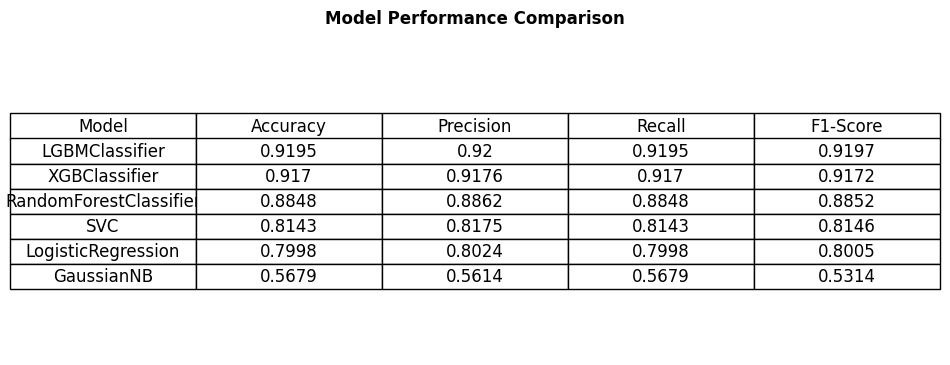

In [157]:
model_metrics  = []

for name , model in train_models.items():
    y_pred = model.predict(X_test)
    report = classification_report(y_test,y_pred,output_dict=True)
    model_metrics.append({
        "Model" : name,
        'Accuracy' : accuracy_score(y_test,y_pred),
        'Precision' : report['weighted avg']['precision'],
        'Recall' : report['weighted avg']['recall'],
        'F1-Score' : report['weighted avg']['f1-score']
    }) 

df_results = pd.DataFrame(model_metrics)
df_results = df_results.sort_values(by='Accuracy',ascending=False).reset_index(drop=True)
print("\n Final model comparision \n")
display(df_results.style.background_gradient(cmap='Blues'))

fig , ax = plt.subplots(figsize=(10,4))
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=df_results.round(4).values, 
                 colLabels=df_results.columns, 
                 loc='center', 
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2,1.5)

plt.title('Model Performance Comparison', fontweight="bold", y=1.05)
plt.show()

In [158]:
# Comparison Table
print("\n--- Model Comparison ---")
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print(f"{'Model':<25} | {'Accuracy':<10}")
print("-" * 37)
for name, score in sorted_results:
    print(f"{name:<25} | {score:.4f}")

best_model_name = sorted_results[0][0]
print(f"\nBest Performing Model: {best_model_name}")


--- Model Comparison ---
Model                     | Accuracy  
-------------------------------------
LGBMClassifier            | 0.9195
XGBClassifier             | 0.9170
RandomForestClassifier    | 0.8848
SVC                       | 0.8143
LogisticRegression        | 0.7998
GaussianNB                | 0.5679

Best Performing Model: LGBMClassifier


In [162]:
import mlflow
import mlflow.sklearn
import dagshub
import os

# DagsHub configuration
DAGSHUB_USERNAME = "sahilshirodkar88"
DAGSHUB_REPO = "CodeBasics_internship_MLflow"
DAGSHUB_TOKEN = "939f45f39e18c7af58bb246336390cc164471ae8"

os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = DAGSHUB_TOKEN

mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow")

mlflow.set_experiment("Mobile Price Range Classification")

print("MLflow connected to DagsHub successfully")

2026/03/03 17:26:28 INFO mlflow.tracking.fluent: Experiment with name 'Mobile Price Range Classification' does not exist. Creating a new experiment.


MLflow connected to DagsHub successfully


In [163]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import matplotlib.pyplot as plt

model_metrics = []

for name, model in model_to_train.items():

    with mlflow.start_run(run_name=name):

        print(f"Training {name}")

        # Train
        model.fit(X_train, y_train)

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)

        precision = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']
        f1 = report['weighted avg']['f1-score']

        # Log Parameters
        mlflow.log_param("model_name", name)

        if hasattr(model, "get_params"):
            for param, value in model.get_params().items():
                mlflow.log_param(param, value)

        # Log Metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)

        # Log Model
        mlflow.sklearn.log_model(model, artifact_path="model")

        # Save metrics locally for comparison table
        model_metrics.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": precision,
            "Recall": recall,
            "F1-Score": f1
        })

        print(f"{name} Logged to MLflow")

Training GaussianNB


2026/03/03 17:28:55 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


GaussianNB Logged to MLflow
🏃 View run GaussianNB at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0/runs/fbbf716c78d14f88804ccf7538d90be3
🧪 View experiment at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0
Training LogisticRegression


2026/03/03 17:29:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression Logged to MLflow
🏃 View run LogisticRegression at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0/runs/e0495ac2622a4a9db28c383943823fb6
🧪 View experiment at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0
Training SVC


...

RandomForestClassifier Logged to MLflow
🏃 View run RandomForestClassifier at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0/runs/50939761ff07467faec64b58a9841c93
🧪 View experiment at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0
Training XGBClassifier


2026/03/03 17:40:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBClassifier Logged to MLflow
🏃 View run XGBClassifier at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0/runs/180f62dcc79d4b1e82cc8f767a3dabd7
🧪 View experiment at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0
Training LGBMClassifier


2026/03/03 17:41:37 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LGBMClassifier Logged to MLflow
🏃 View run LGBMClassifier at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0/runs/1ff3b254cee04552a798b843c7d77847
🧪 View experiment at: https://dagshub.com/sahilshirodkar88/CodeBasics_internship_MLflow.mlflow/#/experiments/0


In [164]:
df_results = pd.DataFrame(model_metrics)
df_results = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("\nFinal Model Comparison\n")
display(df_results)

best_model_name = df_results.iloc[0]["Model"]
print(f"\nBest Performing Model: {best_model_name}")


Final Model Comparison



,Model,Accuracy,Precision,Recall,F1-Score
0,LGBMClassifier,0.919482,0.920024,0.919482,0.919654
1,XGBClassifier,0.917012,0.917585,0.917012,0.917200
2,RandomForestClassifier,0.884764,0.886155,0.884764,0.885155
3,SVC,0.814261,0.817501,0.814261,0.814647
4,LogisticRegression,0.799773,0.802388,0.799773,0.800547
5,GaussianNB,0.567900,0.561423,0.567900,0.531395



Best Performing Model: LGBMClassifier


In [170]:
import joblib

# Select best model
best_model = train_models['XGBClassifier']

# Save the model to a file
joblib.dump(best_model, '../model_data.pkl')

# Save the column names
# Save the columns from X_train to match inputs later
joblib.dump(X_train.columns.tolist(), '../model_columns.pkl')

print("Model and columns saved successfully!")

Model and columns saved successfully!
